# Describing a different dataset: Fisher's irises

*Part 1 · Lesson 1 · another dataset  ·  data: Iris flowers (150 blooms, 3 species)*

*↩ A companion to [Lesson 1: Describing a real dataset](01-describing-data.ipynb).*

**↩ Back:** [Lesson 1: Describing a real dataset](01-describing-data.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](01-describing-data~the-code.ipynb)

**In Lesson 1 you described penguins; here we describe irises, and notice what changes.** We're asking
the *same* first questions of a brand-new dataset — center, spread, shape, correlation, and z-scores —
but on **Fisher's irises**: 150 flowers, three species (setosa, versicolor, virginica), each measured
four ways in centimetres.

Why repeat the drill on different flowers? Because the *habit* matters more than any one dataset, and
because irises are famously **clean** — three perfectly balanced groups, nearly symmetric distributions,
and one pair of measurements that fall almost on a straight line. Watching the same tools behave like a
textbook here (when the penguins were a little messier) teaches you what "well-behaved data" even looks
like — and where the tidy numbers can *still* mislead you.

Read it, run it, look at the picture, then **tinker** (change a number and re-run).

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

IRIS_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv'
iris = sl.load_csv('iris.csv', url=IRIS_URL)

# The file ships with a 'rownames' index column we don't need — drop it.
iris = iris.drop(columns=['rownames'])
# The four measurement columns have a dot in the name, so use bracket access:
# iris['Petal.Length'], not iris.Petal.Length.
print(f'{len(iris)} irises, {iris.shape[1]} columns')
iris.head()

150 irises, 5 columns


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## What kind of data is this?

Same opening question as the penguins lesson: *what is each column?* Statisticians sort variables by
their **level of measurement**, because it decides which tools are allowed.

| Level | Meaning | Example here |
|---|---|---|
| **Nominal** | named categories, no order | `Species` |
| **Ordinal** | ordered categories, uneven gaps | (none here) |
| **Interval** | numbers, no true zero | (none here) |
| **Ratio** | numbers with a true zero (0 = none) | `Sepal.Length`, `Sepal.Width`, `Petal.Length`, `Petal.Width` |

All four measurements are **ratio** data — 0 cm really means "no length," so it's meaningful to say one
petal is *twice* as long as another. That's why means, ratios and z-scores all make sense here.

One thing already stands out versus the penguins: the species column is **perfectly balanced**. Let's
confirm it before we trust any group comparison later.

In [2]:
print('Count of each species:')
print(iris['Species'].value_counts())
print(f"\nThree groups of exactly 50 each — a perfectly balanced, tidy design.")
print('(The penguins were uneven: more Adelie than Chinstrap. Real field data rarely splits this evenly.)')

Count of each species:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Three groups of exactly 50 each — a perfectly balanced, tidy design.
(The penguins were uneven: more Adelie than Chinstrap. Real field data rarely splits this evenly.)


In [3]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


*You'll see **`NaN`** in some boxes above — it just means "not applicable here," e.g. you can't take an
average of a word like a species name. It's normal, not an error.*

## 1) Measures of center — "what's typical?"

Three ways to answer "what's a typical value?", exactly as in Lesson 1:

- **Mean** (the average): $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — add them all up, divide by how many.
- **Median**: the middle value when sorted. Half below, half above.
- **Mode**: the most common value. Most natural for *categories*.

**Meaning:** the mean uses every value (so a few giants pull it up); the median just asks "who's in the
middle?" (so extremes barely move it).

**Interpretation:** when the mean and median land close together, "typical" is a trustworthy summary;
when they drift apart, the data is hiding something. Watch for a gap between them below — it's the first
clue that one overall number won't describe these petals well (we'll see why in section 3).

In [4]:
petal_len = iris['Petal.Length']
print(f"Mean petal length:   {petal_len.mean():.2f} cm")
print(f"Median petal length: {petal_len.median():.2f} cm")
print(f"Mean - median gap:   {petal_len.mean() - petal_len.median():+.2f} cm   (the split hints at the two clumps in section 3)")
# Mode is most natural for a category:
print(f"\nMost common species (mode): {iris['Species'].mode()[0]}  (a 3-way tie at 50 each)")

Mean petal length:   3.76 cm
Median petal length: 4.35 cm
Mean - median gap:   -0.59 cm   (the split hints at the two clumps in section 3)

Most common species (mode): setosa  (a 3-way tie at 50 each)


## 2) Measures of spread — "how varied are they?"

A typical value isn't enough — we need to know how *spread out* the flowers are.

- **Range** = max - min (simple, but only sees the two extremes).
- **Variance**: $\displaystyle s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$ — the average *squared* distance from the mean.
- **Standard deviation**: $s=\sqrt{s^2}$ — back in the original units (cm), so it's readable.
- **IQR** (interquartile range) = 75th - 25th **percentile** — the width of the middle 50%, and it ignores outliers. (A *percentile* is the value a given share falls below: the 25th percentile is the length a quarter of flowers fall *under*.)

**Meaning:** standard deviation is the everyday "give or take." A mean petal of ~3.76 cm with an SD of
~1.77 cm means a typical petal is *3.76 cm, give or take ~1.77 cm.*

**Interpretation:** keep an eye on that SD — for *all* the flowers together it's large, because we've
secretly mixed three different species into one pile. We'll see in section 3 why that overall spread is
hiding something.

In [5]:
print(f"Range:    {petal_len.max() - petal_len.min():.1f} cm")
print(f"Variance: {petal_len.var(ddof=1):.2f} cm^2   (squared units - hard to read)")
print(f"Std dev:  {petal_len.std(ddof=1):.2f} cm   (the everyday 'give or take')")
q1, q3 = petal_len.quantile([0.25, 0.75])
print(f"IQR:      {q3 - q1:.2f} cm   (width of the middle 50%)")

Range:    5.9 cm
Variance: 3.12 cm^2   (squared units - hard to read)
Std dev:  1.77 cm   (the everyday 'give or take')
IQR:      3.50 cm   (width of the middle 50%)


## 3) Shape — *picture* the whole distribution

Numbers summarize; a **histogram** shows the full story — where values cluster, whether it's symmetric or
skewed, and whether there are surprises. **Skew** is a single number for lopsidedness: near 0 means
symmetric, positive means a longer tail to the *right*, negative means a longer tail to the *left*.

Let's compute the skew of every measurement and then *look* at petal length.

In [6]:
measures = ['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']
print('Skew of each measurement (0 = perfectly symmetric):')
for col in measures:
    print(f"  {col:<14} skew = {iris[col].skew():+.2f}")
print('\nEvery skew is small — all within about +/- 0.3 of zero.')
print('Contrast Lesson 1: real, messy data is often clearly lopsided; here it is almost textbook-symmetric.')

Skew of each measurement (0 = perfectly symmetric):
  Sepal.Length   skew = +0.31
  Sepal.Width    skew = +0.32
  Petal.Length   skew = -0.27
  Petal.Width    skew = -0.10

Every skew is small — all within about +/- 0.3 of zero.
Contrast Lesson 1: real, messy data is often clearly lopsided; here it is almost textbook-symmetric.


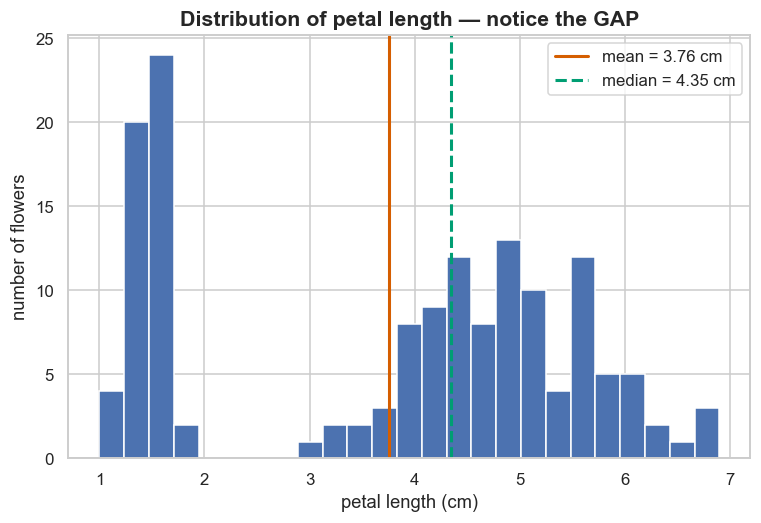

See the empty stretch around 2-3 cm? That hole splits the data into TWO clumps.


In [7]:
fig, ax = plt.subplots()
ax.hist(petal_len, bins=25, color='#4c72b0', edgecolor='white')
ax.axvline(petal_len.mean(), color='#D55E00', lw=2, label=f'mean = {petal_len.mean():.2f} cm')
ax.axvline(petal_len.median(), color='#009E73', lw=2, ls='--', label=f'median = {petal_len.median():.2f} cm')
ax.set_xlabel('petal length (cm)'); ax.set_ylabel('number of flowers')
ax.set_title('Distribution of petal length — notice the GAP')
ax.legend(); plt.show()
print('See the empty stretch around 2-3 cm? That hole splits the data into TWO clumps.')

### The overall summary hides the groups

That histogram is the punchline of this lesson. There's a low, lonely cluster of very short petals near
1-2 cm, an empty gap, and then a big mass from about 3 cm up. A distribution with two separate humps like
this is called **bimodal**. The mean (the red line, at 3.76 cm) lands in a **low-density no-man's-land**
at the near edge of that big mass — only a handful of flowers sit anywhere near it, so it describes almost
**no actual flower**.

What's going on? That short cluster is one whole species (**setosa**), sitting far apart from the other
two. The single overall mean and SD quietly average across three different kinds of flower and produce a
number that fits none of them. This is the same warning the penguins gave — **a summary of a mixed pile
can describe nobody** — but here it's dramatic: the groups don't just differ, they barely overlap. The
fix is always the same: **describe by group.**

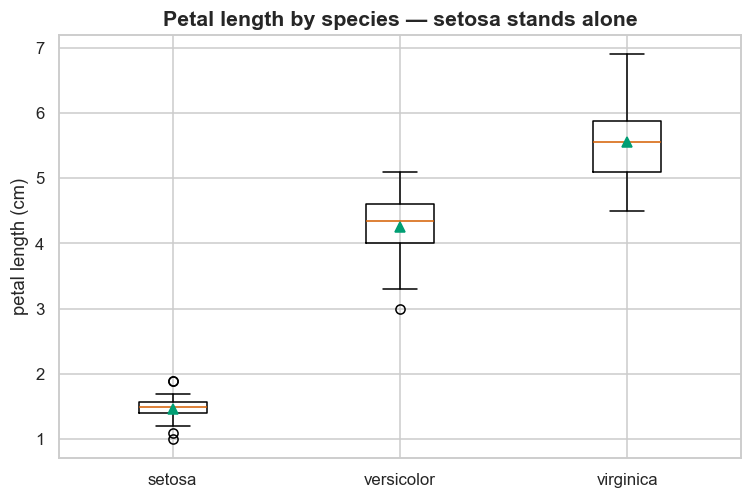

Mean and SD of petal length WITHIN each species:
  setosa       mean = 1.46 cm,  SD = 0.17 cm
  versicolor   mean = 4.26 cm,  SD = 0.47 cm
  virginica    mean = 5.55 cm,  SD = 0.55 cm

setosa is an extremely TIGHT group: tiny SD, all its petals nearly identical.
The overall SD looked big only because we had mixed three species together.


In [8]:
species_order = ['setosa', 'versicolor', 'virginica']
groups = [iris.loc[iris['Species'] == s, 'Petal.Length'] for s in species_order]
fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=species_order, showmeans=True)
ax.set_ylabel('petal length (cm)'); ax.set_title('Petal length by species — setosa stands alone')
plt.show()
print('Mean and SD of petal length WITHIN each species:')
for s in species_order:
    g = iris.loc[iris['Species'] == s, 'Petal.Length']
    print(f"  {s:<12} mean = {g.mean():.2f} cm,  SD = {g.std(ddof=1):.2f} cm")
print('\nsetosa is an extremely TIGHT group: tiny SD, all its petals nearly identical.')
print('The overall SD looked big only because we had mixed three species together.')

## 4) Relationships — do two measurements move together?

A **scatterplot** plots two numbers against each other. **Correlation** ($r$, between -1 and +1)
summarizes the straight-line trend: +1 perfectly up, 0 no linear trend, -1 perfectly down.

In the penguins, flipper length and body mass were strongly linked but still a fuzzy cloud. Here we pick
the pair iris is famous for — **petal length vs. petal width** — and the dots fall almost exactly on a
line.

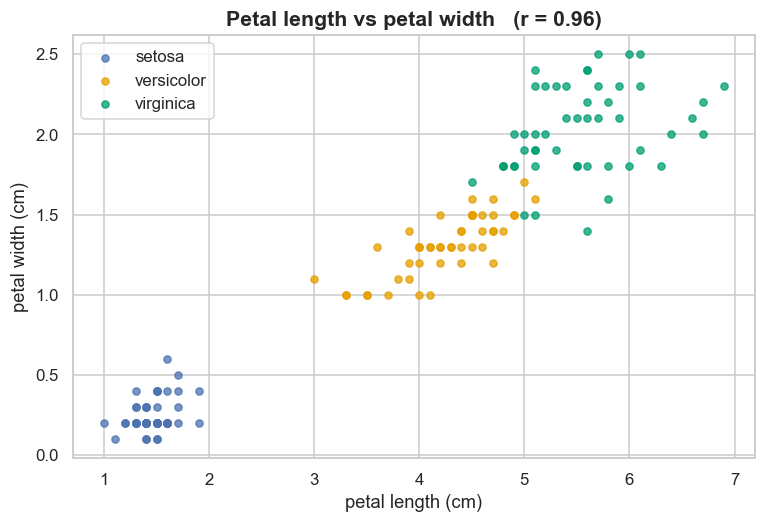

Correlation r = 0.963  ->  almost a straight line: a longer petal is a wider petal, nearly exactly.
This is far tighter than the flipper-vs-mass link in Lesson 1. Iris really is a clean dataset.


In [9]:
r = iris['Petal.Length'].corr(iris['Petal.Width'])
colors = {'setosa': '#4c72b0', 'versicolor': '#E69F00', 'virginica': '#009E73'}
fig, ax = plt.subplots()
for s in species_order:
    sub = iris[iris['Species'] == s]
    ax.scatter(sub['Petal.Length'], sub['Petal.Width'], s=22, alpha=0.75, label=s, color=colors[s])
ax.set_xlabel('petal length (cm)'); ax.set_ylabel('petal width (cm)')
ax.set_title(f'Petal length vs petal width   (r = {r:.2f})')
ax.legend(); plt.show()
print(f'Correlation r = {r:.3f}  ->  almost a straight line: a longer petal is a wider petal, nearly exactly.')
print('This is far tighter than the flipper-vs-mass link in Lesson 1. Iris really is a clean dataset.')

An $r$ this close to +1 means petal length and petal width carry almost the *same* information — knowing
one tells you the other to within a hair. That's much stronger than the penguin relationship, and it's
why iris is the classic dataset for demonstrating tidy linear structure. (A caution we'll meet later:
*correlation isn't causation* — neither petal dimension is "causing" the other; they grow together.)

## 5) z-scores — "how unusual is one flower?"

A **z-score** rescales a value into "how many standard deviations from the mean":

$$z = \frac{x - \bar{x}}{s}$$

$z = 0$ is exactly average; $z = +2$ means "2 SDs above the mean" (large); $z = -1.5$ means "1.5 SDs
below" (small). It lets you compare values measured on different scales — and it's the same recipe you
used on the penguins.

In [10]:
iris = iris.assign(petal_len_z=(petal_len - petal_len.mean()) / petal_len.std(ddof=1))
within1 = (iris['petal_len_z'].abs() < 1).mean() * 100
print(f"{within1:.0f}% of flowers are within 1 SD of the overall mean petal length.")

longest = iris.loc[iris['petal_len_z'].idxmax()]
print(f"Longest petal: {longest['Petal.Length']:.1f} cm  (z = {longest['petal_len_z']:+.2f}, a {longest['Species']}).")

# A z-score is most telling WITHIN a group. Take a single 1.7 cm petal:
setosa = iris[iris['Species'] == 'setosa']
z_overall  = (1.7 - petal_len.mean()) / petal_len.std(ddof=1)
z_in_group = (1.7 - setosa['Petal.Length'].mean()) / setosa['Petal.Length'].std(ddof=1)
print(f"\nA 1.7 cm petal scores z = {z_overall:+.2f} against ALL irises -> BELOW the overall")
print(f"mean of {petal_len.mean():.2f} cm (it sits down in the short-petaled setosa clump).")
print(f"But among setosa alone (mean ~1.46, SD ~0.17 cm) it scores z = {z_in_group:+.2f}")
print(f"-> unusually LONG *for a setosa*. Same petal, opposite verdict.")
print('Lesson: which mean and SD you standardize against completely changes the verdict.')

50% of flowers are within 1 SD of the overall mean petal length.
Longest petal: 6.9 cm  (z = +1.78, a virginica).

A 1.7 cm petal scores z = -1.17 against ALL irises -> BELOW the overall
mean of 3.76 cm (it sits down in the short-petaled setosa clump).
But among setosa alone (mean ~1.46, SD ~0.17 cm) it scores z = +1.37
-> unusually LONG *for a setosa*. Same petal, opposite verdict.
Lesson: which mean and SD you standardize against completely changes the verdict.


## Now you try

Predict what will happen *before* you run each change:

1. Swap `Petal.Length` for `Sepal.Length` or `Sepal.Width` in the center/spread/shape cells. Does the
   histogram still show a clean gap, or do the species blur together? (Hint: sepals overlap far more than
   petals — the species are harder to separate.)

2. In the histogram, change `bins=25` to `bins=10` or `bins=60`. Does the gap between the setosa clump
   and the rest survive a coarser view?

3. **Describe just one species.** Add a new cell (the **+** button in the toolbar), type these two lines,
   and run them with Shift+Enter:

       virginica = iris[iris['Species'] == 'virginica']
       virginica['Petal.Length'].describe()

   How does virginica's mean petal length and SD compare to the all-flowers numbers from section 1-2?

4. **Try a weaker correlation.** Change the scatter to `Sepal.Length` vs `Sepal.Width` and recompute `r`.
   Is it anywhere near the ~0.96 you got for petals? (It isn't — sepals barely correlate overall.)

## What you learned

- The **same four questions** — center, spread, shape, relationships (plus z-scores) — describe *any*
  dataset. Here they ran on irises instead of penguins.
- Iris is the famously **clean** teaching dataset: three perfectly balanced groups of 50, every skew
  small (within about ±0.3 of zero), so the summary statistics behave almost like a textbook — unlike
  the messier penguins.
- **Petal length and petal width are nearly a straight line** ($r \approx 0.96$), a far stronger
  relationship than the penguin measurements showed.
- Within a single species the spread can be tiny — **setosa**'s petals cluster around 1.46 cm with an SD
  of only ~0.17 cm.
- Even clean data can fool you: the overall petal-length histogram is **bimodal**, and the overall mean
  lands in an empty gap describing no real flower. The cure is the same as always — **always look within
  groups.**

**Back to the core lesson** to keep moving through the course, or revisit Lesson 1's penguins to compare
the two side by side.

---

**↩ Back to the lesson:** [Lesson 1: Describing a real dataset](01-describing-data.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](01-describing-data~the-code.ipynb)